# Region space built from a decoder instead of a shape distance

Figure 1g puts the three simulated fields in a common space by computing the **Procrustes
distance** between every pair of regions, embedding the $K \times K$ matrix by classical MDS, and
asking whether the regions are lumpy -- best silhouette over $k$ against a Gaussian matched to
the embedding. Only the field built from three discrete kinds exceeds its null.

This notebook replaces the distance with a **decoder** and changes nothing else. For every pair
of regions a classifier is asked: *given one neuron, which of these two regions is it from?* The
$K \times K$ matrix of cross-validated accuracies goes through the same embedding and the same
test, and the numbers are reported beside the published Procrustes ones.

The question is whether region space needs a shape metric, or whether a decoder gets there too.

Everything is reused: the simulation from `region_space.py` unchanged, the decoder from
`shapemetrics.decoding`, and the embedding and clustering test from `region_space` itself
(`pca_embed`, `continuum_or_types`) -- the very functions figure 1g calls.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

HERE = next(p for p in (Path.cwd(), Path.cwd() / "clustering-simulation",
                        *Path.cwd().parents)
            if (p / "region_space.py").exists())
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))
import region_space as R
import shapemetrics as sm

OUT = HERE / "results"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# figure 1's house style, unchanged
PANEL = 2.1
OBS, NULLC, GREY = "#B22222", "#1F6FB2", "0.75"
KIND_COLORS = ["#B22222", "#1F6FB2", "#E8A33D"]
N_DRAWS = 200

NAMES = ("continuum", "no_gradient", "kinds")
LAB = {"continuum": "gradient", "no_gradient": "unstructured", "kinds": "clustered"}
iu = np.triu_indices(R.N_REGIONS, 1)
print(f"{R.N_REGIONS} regions x {R.N_NEURONS} neurons")

60 regions x 100 neurons


## What is being decoded, and from what

**One sample is one neuron.** The label is which of the two regions it came from, and the
features are its two shape coordinates -- skew and width. `region_space` builds the tuning curves
as $X = \mathrm{MEAN} + \mathrm{SCALE}\cdot W\,\mathrm{MODES}$ with `MODES` orthonormal, so the
weights come straight back out. This is the space figure 1c plots its neuron clouds in.

Using the two coordinates rather than the 120 $\theta$ bins is not a shortcut. PCA on the raw
curves returns explained-variance ratios of $[0.634, 0.365, 10^{-5}, \dots]$: the generator spans
exactly two dimensions and the remaining 118 are noise. Both are run below; the choice makes no
difference to the conclusion.

### One fact that decides how to read everything after it

`region_weights` draws the long-axis coordinate from a symmetric $\pm a\sigma$ mixture and the
short-axis one from a zero-mean Gaussian, so $\mathbb{E}[W] = 0$ for **every** region whatever
`amount` and `kind` are. Every region has the same mean tuning curve, and both knobs move only
the *second* moment -- which is exactly what a Procrustes comparison of regions sees.

A **linear** decoder is therefore blind here by construction, not by weakness. It is kept as a
control precisely because that is worth showing: the default choice of decoder fails on a field
whose region structure is unmissable. **QDA** models each class as a Gaussian and can see a
covariance difference, so it is the one that stands a chance.

In [2]:
def shape_coords(X):
    '''The generator's own 2-D space: (skew, width) per neuron.'''
    return (X - R.MEAN) @ R.MODES.T / R.SCALE


MODELS = {"linear": lambda: sm.decoding.classifier(),   # logistic regression
          "quadratic": lambda: QDA(reg_param=0.05)}

# every region shares one mean, so there is no first-moment signal at all
X, region, colour = R.scenario("kinds")
M = np.stack([shape_coords(X)[region == r].mean(0) for r in np.unique(region)])
print(f"spread of region mean shape coordinates : {M.std(0).mean():.2e}")
print(f"spread of neurons within a region       : {shape_coords(X).std(0).mean():.2e}")
print(f"separation of the three kind centroids  : "
      f"{np.std([M[colour == k].mean(0) for k in range(R.N_KINDS)], axis=0).mean():.2e}")

spread of region mean shape coordinates : 6.94e-02
spread of neurons within a region       : 7.27e-01
separation of the three kind centroids  : 6.17e-03


## The decoding matrices

`sm.decoding_matrix` mirrors `sm.distance_matrix`: it takes `neurons x features` and the region
labels, and returns the $K \times K$ matrix. Every region has the same 100 neurons here, so no
subsampling is needed -- chance is 0.5 for every pair by construction.

Each matrix comes with a **label shuffle**: the same estimator, the same folds, nothing left to
learn. It says where "no difference" actually falls, which matters because cross-validation at
100 neurons per class hands out a little accuracy for free.

About 11 minutes for the six matrices, so they are cached.

In [3]:
f = OUT / "region_decoding_shape.npz"
if f.exists():
    dec = np.load(f, allow_pickle=True)["res"].item()
else:
    dec = {}
    for name in NAMES:
        W = shape_coords(R.scenario(name)[0])
        for mname, model in MODELS.items():
            dec[(name, mname)] = dict(
                A=sm.decoding_matrix(W, R.scenario(name)[1], model=model()),
                S=sm.decoding_matrix(W, R.scenario(name)[1], model=model(), shuffle=True))
    np.savez(f, res=np.array(dec, dtype=object))

print(f"{'':>14}{'linear':>22}{'quadratic':>22}")
print(f"{'':>14}{'acc':>10}{'shuffle':>12}{'acc':>10}{'shuffle':>12}")
for name in NAMES:
    row = "".join(f"{dec[(name, m)]['A'][iu].mean():>10.3f}"
                  f"{dec[(name, m)]['S'][iu].mean():>12.3f}"
                  for m in ("linear", "quadratic"))
    print(f"{LAB[name]:>14}{row}")

                              linear             quadratic
                     acc     shuffle       acc     shuffle
      gradient     0.510       0.500     0.570       0.500
  unstructured     0.510       0.501     0.571       0.502
     clustered     0.504       0.508     0.687       0.506


## Panel g's test, on those matrices

Three steps, all of them `region_space`'s own:

1. **anchor at chance.** An accuracy matrix is not a dissimilarity: $d(i,i) = 0$, but two
   *identical* regions score 0.5, so MDS would read that step as structure. $\delta_{ij} =
   \max(\mathrm{acc}_{ij} - 0.5,\, 0)$ with a zero diagonal fixes it.
2. **embed** with `R.pca_embed` -- classical MDS, deterministic, axes ordered by variance.
3. **test** with `R.continuum_or_types` -- best silhouette over $k$ against 200 Gaussians matched
   to the embedding.

Then the readout figure 1 reports for each field: the ratio of between-kind centroid separation
to within-kind spread for the clustered one, and for the two graded fields
$|\rho(\text{categoricality}, \mathrm{PC}1)|$ -- whether a region's position in region space
predicts how categorical its own neurons are.

### Why not $|\rho(\mathrm{PC}1, \text{position along } \psi)|$

Because it cannot tell the two graded fields apart, and reporting it invites exactly that
mistake. `no_gradient` permutes **only** `amounts`; `psis` still sweeps smoothly with $t$, and a
region's geometry depends on $\psi$ and not on $a$ -- the generator holds the variance along the
long axis at $\sigma_L^2$ for every `amount`. Scenarios 1 and 2 therefore have **identical region
spaces by construction**, and both recover the $\psi$ ordering at $|\rho|$ = 0.96.

What scenario 2 destroys is not the ordering of region space but the *coupling* between that
ordering and within-region categoricality. So the $\psi$ correlation is worth reporting as a
check that the embedding is ordered at all, and it is printed below for that reason -- but the
contrast between the two fields lives in $|\rho(\text{categoricality}, \mathrm{PC}1)|$.

In [4]:
def dissimilarity(A):
    D = np.clip(A - 0.5, 0, None)
    np.fill_diagonal(D, 0.0)
    return D


def kinds_ratio(E, colour):
    sep = np.mean([np.linalg.norm(E[colour == i].mean(0) - E[colour == j].mean(0))
                   for i in range(R.N_KINDS) for j in range(i + 1, R.N_KINDS)])
    within = np.mean([E[colour == k].std(0).mean() for k in range(R.N_KINDS)])
    return sep / within


def readout(name, E, colour, z=None):
    '''The number figure 1g reports for this field.

    For the clustered field, how separated the three kinds are. For the two graded
    fields, |rho(categoricality, region PC1)| -- and NOT |rho(PC1, colour)|, which
    is a trap here. `colour` is t, the psi ordering, and `no_gradient` permutes only
    `amounts`: psi still sweeps smoothly and region geometry depends on psi and not
    on a, so the two fields have IDENTICAL region spaces and both score 0.96.  What
    scenario 2 destroys is the COUPLING between a region's categoricality and its
    position, which is what this measures instead.
    '''
    if name == "kinds":
        return kinds_ratio(E, colour)
    return abs(stats.spearmanr(z, E[:, 0]).statistic)


proc = np.load(OUT / "region_3x4.npz", allow_pickle=True)["res"].item()
CAT = {n: proc[n]["z"] for n in NAMES}          # per-region categoricality, figure 1d


def entry(name, E, ct):
    colour = R.scenario(name)[2]
    return dict(E=E, ct=ct, colour=colour,
                readout=readout(name, E, colour, CAT[name]),
                psi_rho=abs(stats.spearmanr(colour, E[:, 0]).statistic))


res = {}
for mname in MODELS:
    for name in NAMES:
        E = R.pca_embed(dissimilarity(dec[(name, mname)]["A"]))
        res[(mname, name)] = entry(name, E, R.continuum_or_types(E, N_DRAWS))
for name in NAMES:
    res[("procrustes", name)] = entry(name, proc[name]["emb"], proc[name]["ct"])

hdr = f"{'':>14}{'silhouette':>12}{'null':>9}{'z':>8}{'p':>8}   readout"
print("(|rho(PC1, psi ordering)| is reported separately below: it is 0.96 in BOTH")
print(" graded fields by construction, so it cannot tell them apart.)")
for mname in ("procrustes", "quadratic", "linear"):
    print(f"\n--- {mname} " + "-" * (62 - len(mname)))
    print(hdr)
    for name in NAMES:
        r = res[(mname, name)]
        tag = "kinds sep/within" if name == "kinds" else "|rho(categoricality, PC1)|"
        print(f"{LAB[name]:>14}{r['ct']['obs']:>12.3f}{r['ct']['null'].mean():>9.3f}"
              f"{r['ct']['z']:>+8.2f}{r['ct']['p']:>8.3f}   {tag} = {r['readout']:.2f}")

(|rho(PC1, psi ordering)| is reported separately below: it is 0.96 in BOTH
 graded fields by construction, so it cannot tell them apart.)

--- procrustes ----------------------------------------------------
                silhouette     null       z       p   readout
      gradient       0.309    0.287   +0.88   0.199   |rho(categoricality, PC1)| = 0.72
  unstructured       0.288    0.292   -0.17   0.557   |rho(categoricality, PC1)| = 0.06
     clustered       0.721    0.396   +9.83   0.005   kinds sep/within = 13.17

--- quadratic -----------------------------------------------------
                silhouette     null       z       p   readout
      gradient       0.380    0.350   +0.93   0.179   |rho(categoricality, PC1)| = 0.73
  unstructured       0.369    0.338   +0.94   0.169   |rho(categoricality, PC1)| = 0.02
     clustered       0.701    0.336  +13.14   0.005   kinds sep/within = 11.20

--- linear --------------------------------------------------------
                silho

In [5]:
# the psi-ordering check: high in BOTH graded fields, by construction
print(f"{'':>14}{'|rho(PC1, psi ordering)|':>26}")
for mname in ("procrustes", "quadratic", "linear"):
    row = "".join(f"{res[(mname, n)]['psi_rho']:>12.2f}"
                  for n in ("continuum", "no_gradient"))
    print(f"{mname:>14}{row}   (gradient, unstructured)")

                |rho(PC1, psi ordering)|
    procrustes        0.96        0.96   (gradient, unstructured)
     quadratic        0.96        0.96   (gradient, unstructured)
        linear        0.18        0.19   (gradient, unstructured)


### Does the feature choice matter?

The same thing on the raw 120-bin tuning curves, per-neuron standardised as the clustering
pipeline does. If the conclusion moved, the shape coordinates would be doing the work rather than
the decoder.

In [6]:
f = OUT / "region_decoding.npz"
if f.exists():
    curve = np.load(f, allow_pickle=True)["res"].item()
    print(f"{'':>14}{'silhouette':>12}{'z':>8}{'p':>8}   readout")
    for mname in ("quadratic", "linear"):
        print(f"--- {mname}, 120-bin curves " + "-" * (34 - len(mname)))
        for name in NAMES:
            colour = R.scenario(name)[2]
            E = R.pca_embed(dissimilarity(curve[(name, mname)]["A"]))
            ct = R.continuum_or_types(E, N_DRAWS)
            tag = ("kinds sep/within" if name == "kinds"
                   else "|rho(categoricality, PC1)|")
            print(f"{LAB[name]:>14}{ct['obs']:>12.3f}{ct['z']:>+8.2f}{ct['p']:>8.3f}"
                  f"   {tag} = {readout(name, E, colour, CAT[name]):.2f}")
else:
    print("results/region_decoding.npz not found -- the 120-bin control was not run")

                silhouette       z       p   readout
--- quadratic, 120-bin curves -------------------------


      gradient       0.383   +1.07   0.154   |rho(categoricality, PC1)| = 0.73


  unstructured       0.362   +0.90   0.194   |rho(categoricality, PC1)| = 0.02


     clustered       0.698  +13.02   0.005   kinds sep/within = 11.11
--- linear, 120-bin curves ----------------------------


      gradient       0.169   -2.09   0.995   |rho(categoricality, PC1)| = 0.49


  unstructured       0.179   -1.52   0.950   |rho(categoricality, PC1)| = 0.35


     clustered       0.256   +2.38   0.025   kinds sep/within = 1.01


## The figure

Figure 1g's bottom two rows, redrawn from the decoder: the three fields in region space, and
beneath each the best silhouette against its Gaussian null. The Procrustes row is included so the
three can be read against one another.

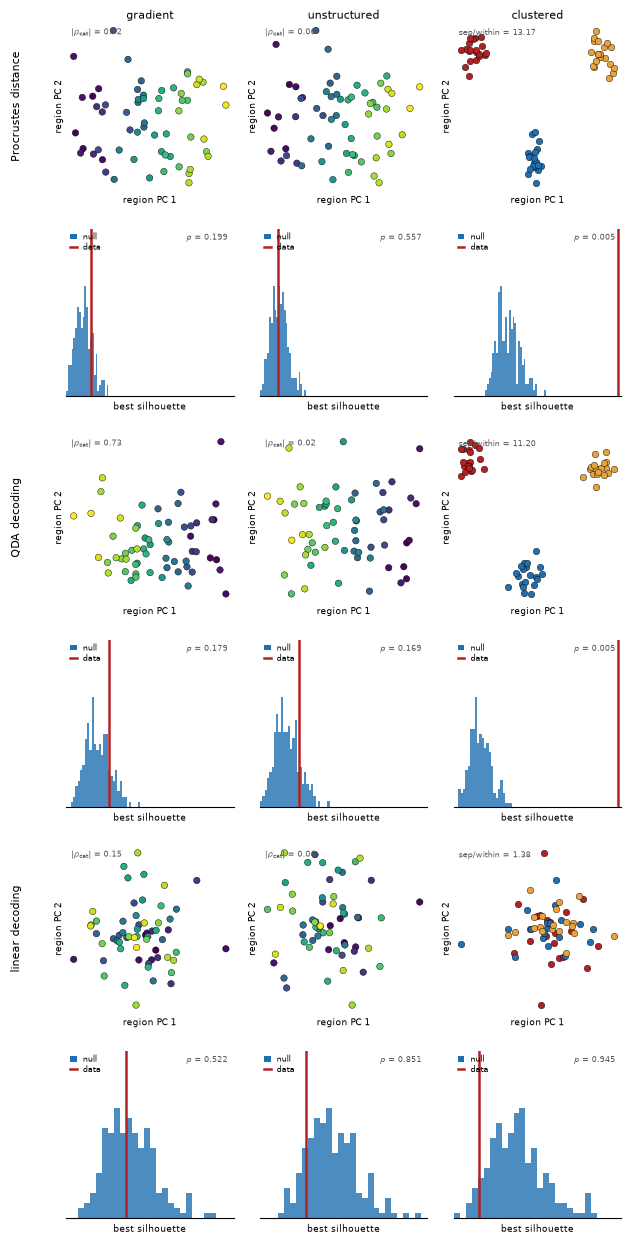

In [7]:
ROWS = [("procrustes", "Procrustes distance"),
        ("quadratic", "QDA decoding"),
        ("linear", "linear decoding")]

fig, axes = plt.subplots(len(ROWS) * 2, 3, figsize=(3 * PANEL, len(ROWS) * 2 * PANEL))

for r_, (mname, rowlab) in enumerate(ROWS):
    # one silhouette scale per row: the value depends on the embedding, so only
    # where the observed value falls in its OWN null is comparable across fields
    _v = np.concatenate([np.r_[res[(mname, n)]["ct"]["null"],
                               res[(mname, n)]["ct"]["obs"]] for n in NAMES])
    binw = min(np.ptp(res[(mname, n)]["ct"]["null"]) for n in NAMES) / 22
    sbins = np.arange(np.floor(_v.min() / binw) * binw, _v.max() + 2 * binw, binw)

    for c_, name in enumerate(NAMES):
        r = res[(mname, name)]
        E, colour, ct = r["E"], r["colour"], r["ct"]

        ax = axes[2 * r_, c_]
        if name == "kinds":
            for k in range(R.N_KINDS):
                m = colour == k
                ax.scatter(E[m, 0], E[m, 1], c=KIND_COLORS[k], s=22, edgecolor="black",
                           linewidths=0.3, label=f"kind {k + 1}")
        else:
            ax.scatter(E[:, 0], E[:, 1], c=colour, cmap="viridis", s=22,
                       edgecolor="black", linewidths=0.3)
        ax.set(xticks=[], yticks=[])
        ax.set_xlabel("region PC 1", fontsize=6.5)
        ax.set_ylabel("region PC 2", fontsize=6.5, labelpad=2)
        if r_ == 0:
            ax.set_title(LAB[name], fontsize=8, pad=3)
        if c_ == 0:
            ax.text(-0.30, 0.5, rowlab, fontsize=8, rotation=90, va="center",
                    ha="center", transform=ax.transAxes)
        tag = "sep/within" if name == "kinds" else r"$|\rho_{\mathrm{cat}}|$"
        ax.text(0.03, 0.97, f"{tag} = {r['readout']:.2f}", transform=ax.transAxes,
                fontsize=6, va="top", ha="left", color="0.35")
        ax.set_box_aspect(1); sns.despine(ax=ax, left=True, bottom=True)

        ax = axes[2 * r_ + 1, c_]
        ax.hist(ct["null"], bins=sbins, color=NULLC, alpha=0.8)
        ax.axvline(ct["obs"], color=OBS, lw=1.8)
        ax.set_xlim(sbins[0], sbins[-1])
        ax.set(yticks=[], xticks=[])
        ax.set_xlabel("best silhouette", fontsize=6.5)
        ylo, yhi = ax.get_ylim(); ax.set_ylim(ylo, yhi * 1.45)
        ax.legend([Patch(facecolor=NULLC), Line2D([0], [0], color=OBS, lw=1.8)],
                  ["null", "data"], frameon=False, fontsize=5.5, loc="upper left",
                  handlelength=0.9, labelspacing=0.2, borderaxespad=0.1)
        ax.text(0.97, 0.97, f"$p$ = {ct['p']:.3f}", transform=ax.transAxes,
                fontsize=6, va="top", ha="right", color="0.35")
        ax.set_box_aspect(1); sns.despine(ax=ax, left=True)

fig.tight_layout(w_pad=1.4, h_pad=1.2)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_decoding.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()